## Параметры

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, root_scalar
from scipy.special import roots_hermite
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# ---------- Параметры ----------
alpha   = 0.33
betta   = 0.95
delta   = 0.025
theta   = 1.25      # CRRA
psi     = 0.75      # disutility of labor exponent
phi     = 5.0
rho     = 0.7
sigma   = 0.015      # сначала лучше поставить маленький шок, потом можно увеличить

def compute_steady_state():
    R = 1.0 / betta + delta - 1.0
    W = ((1.0 - alpha)**(1.0 - alpha) * alpha**alpha / R**alpha) ** (1.0 / (1.0 - alpha))
    K2L = (W / R) * alpha / (1.0 - alpha)
    C2L = K2L**alpha - delta * K2L
    L = ((W / phi) / C2L**theta) ** (1.0 / (psi + theta))
    K = K2L * L
    C = C2L * L
    Y = K**alpha * L**(1.0 - alpha)
    I = delta * K
    return K, L, C, Y, I, R, W

K_ss, L_ss, C_ss, Y_ss, I_ss, R_ss, W_ss = compute_steady_state()
print(f"SS: K={K_ss:.6f}, C={C_ss:.6f}, L={L_ss:.6f}, Y={Y_ss:.6f}, I={I_ss:.6f}")

# ---------- Границы ----------
K_min, K_max = 0.5 * K_ss, 1.5 * K_ss
std_z_uncond = sigma / np.sqrt(1.0 - rho**2)
z_min, z_max = -3.0 * std_z_uncond, 3.0 * std_z_uncond

n_K = 15
n_Z = 9
n_hermite = 7

SS: K=3.114430, C=0.654800, L=0.359216, Y=0.732661, I=0.077861


## 2. Узлы Чебышёва и базис

In [3]:
def chebyshev_nodes(n, a, b):
    x = np.cos((2.0*np.arange(1, n+1) - 1.0) * np.pi / (2.0*n))
    return 0.5*(a+b) + 0.5*(b-a)*x

def chebyshev_polynomials(x, deg, a, b):
    x = np.atleast_1d(x)
    y = 2.0 * (x - a) / (b - a) - 1.0
    y = np.clip(y, -1.0, 1.0)   # защита от выхода из диапазона
    T = np.zeros((len(x), deg))
    T[:, 0] = 1.0
    if deg > 1:
        T[:, 1] = y
    for k in range(2, deg):
        T[:, k] = 2.0 * y * T[:, k-1] - T[:, k-2]
    return T

K_nodes = np.sort(chebyshev_nodes(n_K, K_min, K_max))
z_nodes = np.sort(chebyshev_nodes(n_Z, z_min, z_max))

T_K = chebyshev_polynomials(K_nodes, n_K, K_min, K_max)
T_z = chebyshev_polynomials(z_nodes, n_Z, z_min, z_max)

## Функции модели

In [4]:
def labor_from_KC(K, C, z):
    if K <= 0 or C <= 1e-12:
        return np.nan
    tfp = np.exp(z)
    rhs = (1.0 - alpha) * tfp * (K ** alpha) / (phi * (C ** theta))
    if rhs <= 0:
        return np.nan
    L = rhs ** (1.0 / (psi + alpha))
    if not np.isfinite(L) or L <= 0:
        return np.nan
    return L

def production(K, L, z):
    return np.exp(z) * (K ** alpha) * (L ** (1.0 - alpha))

def rental_rate(K, L, z):
    Y = production(K, L, z)
    return alpha * Y / K

def wage(K, L, z):
    Y = production(K, L, z)
    return (1.0 - alpha) * Y / L

## 4. Начальное приближение

In [5]:
def solve_C_stationary_given_Kz(K, z):
    def res(C):
        L = labor_from_KC(K, C, z)
        if np.isnan(L):
            return 1e8
        Y = production(K, L, z)
        return Y - C - delta * K

    upper = max(2.0 * Y_ss, 2.0 * C_ss)
    try:
        sol = root_scalar(res, bracket=[1e-8, upper], method='brentq')
        if sol.converged:
            return sol.root
    except:
        pass
    return C_ss

def numerical_elasticity():
    eps = 1e-5

    K_pert = K_ss * (1.0 + eps)
    C_pert_K = solve_C_stationary_given_Kz(K_pert, 0.0)
    eta_c_k = (np.log(C_pert_K) - np.log(C_ss)) / eps

    z_pert = eps
    C_pert_z = solve_C_stationary_given_Kz(K_ss, z_pert)
    eta_c_z = (np.log(C_pert_z) - np.log(C_ss)) / eps

    return eta_c_k, eta_c_z

eta_c_k, eta_c_z = numerical_elasticity()
print(f"eta_c_k = {eta_c_k:.6f}, eta_c_z = {eta_c_z:.6f}")

def initial_C(K, z):
    val = C_ss * np.exp(eta_c_k * np.log(K / K_ss) + eta_c_z * z)
    return max(val, 1e-8)

C_init_grid = np.zeros((n_K, n_Z))
for i, K in enumerate(K_nodes):
    for j, z in enumerate(z_nodes):
        C_init_grid[i, j] = initial_C(K, z)

A = np.kron(T_z, T_K)
c_vec = C_init_grid.T.flatten()
theta_init_flat, _, _, _ = lstsq(A, c_vec, rcond=None)

eta_c_k = 0.256680, eta_c_z = 0.970751


## 5. Гаусс–Эрмит и правильное уравнение Эйлера

In [6]:
herm_nodes, herm_weights = roots_hermite(n_hermite)

def gh_expectation(func, z_current):
    mean = rho * z_current
    std = sigma
    z_next_vals = mean + np.sqrt(2.0) * std * herm_nodes
    weights = herm_weights / np.sqrt(np.pi)
    vals = np.array([func(z_next) for z_next in z_next_vals])
    return np.sum(weights * vals)

## 6. Аппроксимация политики C(K,z)

In [7]:
def C_from_theta(K, z, theta_mat):
    K_eval = np.clip(K, K_min, K_max)
    z_eval = np.clip(z, z_min, z_max)

    T_K_pt = chebyshev_polynomials(np.array([K_eval]), n_K, K_min, K_max).flatten()
    T_z_pt = chebyshev_polynomials(np.array([z_eval]), n_Z, z_min, z_max).flatten()

    C = T_K_pt @ theta_mat @ T_z_pt
    return max(C, 1e-8)

## 7. Исправленная невязка Эйлера

In [8]:
def euler_residuals(theta_flat, K_grid_1d, z_grid_1d, penalty=1e6, debug=False):
    theta_mat = theta_flat.reshape((n_K, n_Z))
    residuals = []

    for i, K in enumerate(K_grid_1d):
        for j, z in enumerate(z_grid_1d):
            C = C_from_theta(K, z, theta_mat)
            L = labor_from_KC(K, C, z)

            if np.isnan(L) or L <= 0:
                residuals.append(penalty)
                continue

            Y = production(K, L, z)
            I = Y - C
            K_next = (1.0 - delta) * K + I

            if (not np.isfinite(K_next)) or (K_next <= 1e-10):
                residuals.append(penalty)
                continue

            # штраф за сильный выход за область
            extra_penalty = 0.0
            if K_next < K_min or K_next > K_max:
                extra_penalty += 1e3 * (min(abs(K_next - K_min), abs(K_next - K_max)) / K_ss) ** 2

            def integrand(z_next):
                C_next = C_from_theta(K_next, z_next, theta_mat)
                L_next = labor_from_KC(K_next, C_next, z_next)

                if np.isnan(L_next) or L_next <= 0:
                    return 0.0

                R_next = rental_rate(K_next, L_next, z_next)

                val = (C / C_next) ** theta * (R_next + 1.0 - delta)
                if not np.isfinite(val):
                    return 0.0
                return val

            rhs = betta * gh_expectation(integrand, z)
            resid = 1.0 - rhs
            residuals.append(resid + extra_penalty)

            if debug and i == len(K_grid_1d)//2 and j == len(z_grid_1d)//2:
                print(f"K={K:.4f}, z={z:.4f}, C={C:.4f}, K_next={K_next:.4f}, resid={resid:.4e}")

    return np.array(residuals)

## 8. Оптимизация

In [22]:
print("Проверка начальной невязки...")
init_res = euler_residuals(theta_init_flat, K_nodes, z_nodes)
print(f"SSR initial = {np.sum(init_res**2):.6e}")
print(f"Max abs residual initial = {np.max(np.abs(init_res)):.6e}")
print("Оптимизация коэффициентов...")
result = minimize(
    lambda th: np.sum(euler_residuals(th, K_nodes, z_nodes)**2),
    theta_init_flat,
    method='L-BFGS-B',
    options={'maxiter': 1500, 'ftol': 1e-12, 'gtol': 1e-8, 'disp': True}
)
theta_opt = result.x.reshape((n_K, n_Z))
print("Status:", result.message)
print(f"Final SSR = {result.fun:.6e}")
res_vec = euler_residuals(result.x, K_nodes, z_nodes, debug=True)
print(f"Max abs residual = {np.max(np.abs(res_vec)):.6e}")

Проверка начальной невязки...
SSR initial = 4.382094e+02
Max abs residual initial = 1.071410e+01
Оптимизация коэффициентов...
Status: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final SSR = 4.382094e+02
K=3.1144, z=0.0000, C=0.6553, K_next=3.1134, resid=-3.1435e-03
Max abs residual = 1.071410e+01


## 9. Визуализация функции политики

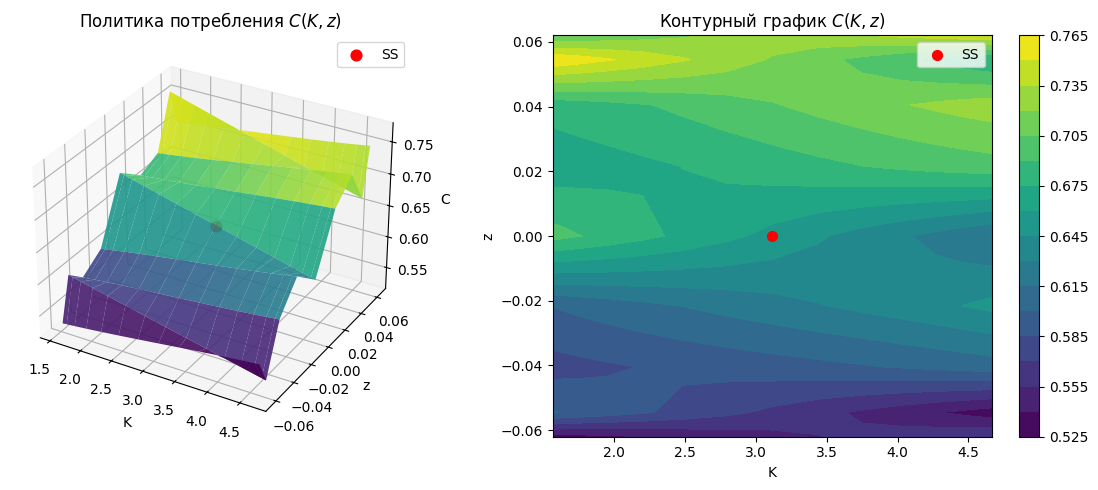

In [23]:
C_opt_grid = np.zeros((n_K, n_Z))
for i, K in enumerate(K_nodes):
    for j, z in enumerate(z_nodes):
        C_opt_grid[i, j] = C_from_theta(K, z, theta_opt)
K_mesh, z_mesh = np.meshgrid(K_nodes, z_nodes, indexing='ij')
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(K_mesh, z_mesh, C_opt_grid, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.scatter([K_ss], [0.0], [C_ss], color='red', s=60, label='SS')
ax1.set_xlabel('K')
ax1.set_ylabel('z')
ax1.set_zlabel('C')
ax1.set_title('Политика потребления $C(K,z)$')
ax1.legend()
ax2 = fig.add_subplot(122)
cont = ax2.contourf(K_mesh, z_mesh, C_opt_grid, levels=20, cmap='viridis')
ax2.scatter([K_ss], [0.0], color='red', s=50, label='SS')
ax2.set_xlabel('K')
ax2.set_ylabel('z')
ax2.set_title('Контурный график $C(K,z)$')
ax2.legend()
plt.colorbar(cont, ax=ax2)
plt.tight_layout()
plt.show()

## 10. Симуляция глобального стохастического решения

In [11]:
def simulate_global_irf(theta_mat, T_sim=40, shock_size=None):
    if shock_size is None:
        shock_size = sigma
    z_path = np.zeros(T_sim)
    z_path[0] = shock_size
    for t in range(1, T_sim):
        z_path[t] = rho * z_path[t-1]
    K_path = np.zeros(T_sim + 1)
    C_path = np.zeros(T_sim)
    L_path = np.zeros(T_sim)
    Y_path = np.zeros(T_sim)
    I_path = np.zeros(T_sim)
    K_path[0] = K_ss
    for t in range(T_sim):
        K_t = K_path[t]
        z_t = z_path[t]
        C_t = C_from_theta(K_t, z_t, theta_mat)
        L_t = labor_from_KC(K_t, C_t, z_t)
        Y_t = production(K_t, L_t, z_t)
        I_t = Y_t - C_t
        K_next = (1.0 - delta) * K_t + I_t
        C_path[t] = C_t
        L_path[t] = L_t
        Y_path[t] = Y_t
        I_path[t] = I_t
        K_path[t+1] = max(K_next, 1e-8)
    return {
        'z': z_path,
        'K': K_path[:-1],
        'C': C_path,
        'L': L_path,
        'Y': Y_path,
        'I': I_path
    }

def pct_dev(x, x_ss):
    return 100.0 * (x / x_ss - 1.0)
sim_global = simulate_global_irf(theta_opt, T_sim=40, shock_size=sigma)

## 11. Графики IRF со стационарным состоянием

In [12]:
def plot_global_irf(sim):
    t = np.arange(len(sim['Y']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Глобальное решение (Чебышёв + Гаусс–Эрмит)', fontsize=18)

    series = [
        ('Y', Y_ss, 'Выпуск Y'),
        ('C', C_ss, 'Потребление C'),
        ('I', I_ss, 'Инвестиции I'),
        ('L', L_ss, 'Труд L'),
    ]

    for ax, (key, ss, title) in zip(axes.ravel(), series):
        ax.plot(t, pct_dev(sim[key], ss), color='blue', lw=2.5, label='Чебышёв')
        ax.axhline(0.0, color='gray', ls=':', lw=1.8, label='SS')
        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

## 12. Как сравнивать с Dynare

In [20]:
def plot_compare_irfs(sim_global, dynare_irfs, T=40):
    t = np.arange(T)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Сравнение: локальное решение (Dynare) vs глобальное решение (Чебышёв)', fontsize=18)

    comparison = [
        ('Y', Y_ss, dynare_irfs['Y'], 'Выпуск Y'),
        ('C', C_ss, dynare_irfs['C'], 'Потребление C'),
        ('I', I_ss, dynare_irfs['I'], 'Инвестиции I'),
        ('L', L_ss, dynare_irfs['L'], 'Труд L'),
    ]

    for ax, (key, ss, dyn, title) in zip(axes.ravel(), comparison):
        glob = pct_dev(sim_global[key][:T], ss)

        ax.plot(t, dyn[:T], 'r--', lw=2.5, label='Dynare')
        ax.plot(t, glob, 'b-', lw=2.2, label='Чебышёв')
        ax.axhline(0.0, color='gray', ls=':', lw=1.6, label='SS')

        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()




# def plot_compare_irfs(sim_global, dynare_irfs, T=40):
#     t = np.arange(T)

#     global_irfs = {
#         "Y": pct_dev(sim_global["Y"][:T], Y_ss),
#         "C": pct_dev(sim_global["C"][:T], C_ss),
#         "I": pct_dev(sim_global["I"][:T], I_ss),
#         "L": pct_dev(sim_global["L"][:T], L_ss),
#     }

#     fig, axes = plt.subplots(2, 2, figsize=(14, 8))
#     fig.suptitle("Сравнение: локальное решение (Dynare) vs глобальное решение (Чебышёв)", fontsize=18)

#     names = [
#         ("Y", "Выпуск Y"),
#         ("C", "Потребление C"),
#         ("I", "Инвестиции I"),
#         ("L", "Труд L"),
#     ]

#     for ax, (key, title) in zip(axes.ravel(), names):
#         dyn = dynare_irfs[key][:T]
#         glob = global_irfs[key]

#         ax.plot(t, dyn, 'r--', lw=2.5, label='Dynare')
#         ax.plot(t, glob, 'b-', lw=2.4, label='Чебышёв')
#         ax.axhline(0.0, color='gray', ls=':', lw=1.6, label='SS')

#         ymin = min(dyn.min(), glob.min())
#         ymax = max(dyn.max(), glob.max())
#         pad = 0.1 * (ymax - ymin + 1e-8)
#         ax.set_ylim(ymin - pad, ymax + pad)

#         ax.set_title(title, fontsize=15)
#         ax.set_xlabel("Периоды")
#         ax.set_ylabel("% отклонения")
#         ax.grid(True, alpha=0.3)
#         ax.legend()

#     plt.tight_layout()
#     plt.show()

In [14]:
def plot_global_levels(sim_global):
    t = np.arange(len(sim_global["Y"]))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("Глобальное решение в уровнях", fontsize=18)

    series = [
        ("Y", Y_ss, "Выпуск Y"),
        ("C", C_ss, "Потребление C"),
        ("I", I_ss, "Инвестиции I"),
        ("L", L_ss, "Труд L"),
    ]

    for ax, (key, ss, title) in zip(axes.ravel(), series):
        ax.plot(t, sim_global[key], 'b-', lw=2.3, label='Чебышёв')
        ax.axhline(ss, color='gray', ls=':', lw=1.6, label='SS')
        ax.set_title(title)
        ax.set_xlabel("Периоды")
        ax.set_ylabel("Уровень")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


In [15]:
def plot_capital_path(sim_global):
    t = np.arange(len(sim_global["K"]))
    plt.figure(figsize=(8, 4.5))
    plt.plot(t, sim_global["K"], lw=2.5, label="K_t")
    plt.axhline(K_ss, color="gray", ls=":", lw=1.6, label="K_ss")
    plt.xlabel("Периоды")
    plt.ylabel("Капитал")
    plt.title("Траектория капитала")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

Первые 5 значений Dynare:
Y: [0.06050803 0.04312899 0.03151103 0.02282894 0.01666632]
C: [0.01778909 0.01660782 0.01548598 0.0142852  0.01312991]
I: [0.04271893 0.02652116 0.01602505 0.00854374 0.00353641]
L: [-0.01095852 -0.00873878 -0.00711108 -0.00595071 -0.00513291]


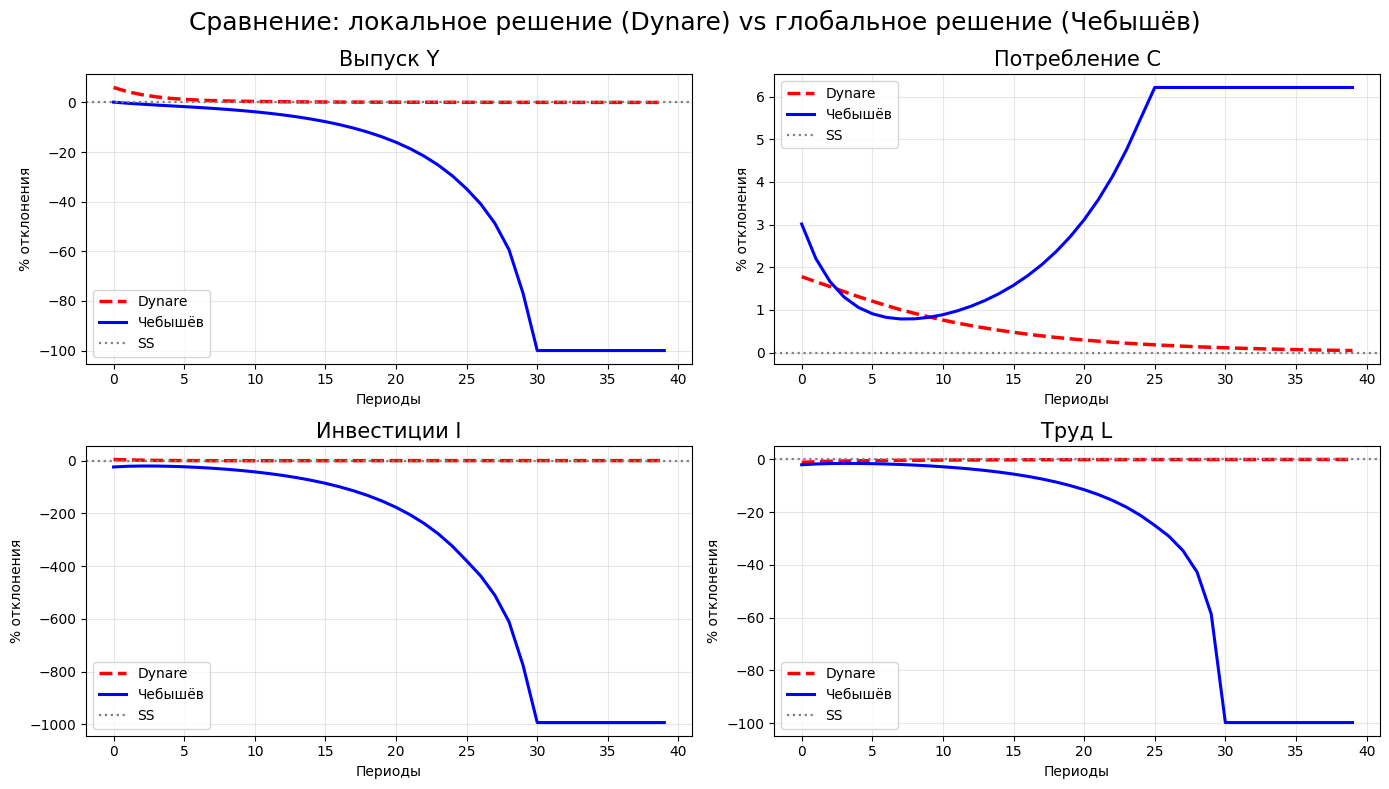

In [24]:
from scipy.io import loadmat
import numpy as np

mat = loadmat("dynare_irf.mat")

y_dyn = np.array(mat["Y_irf"]).flatten()
c_dyn = np.array(mat["C_irf"]).flatten()
i_dyn = np.array(mat["I_irf"]).flatten()
l_dyn = np.array(mat["L_irf"]).flatten()

print("Первые 5 значений Dynare:")
print("Y:", y_dyn[:5])
print("C:", c_dyn[:5])
print("I:", i_dyn[:5])
print("L:", l_dyn[:5])

# Вариант 1: Dynare в долях -> переводим в %
dynare_irfs = {
    "Y": 100 * y_dyn,
    "C": 100 * c_dyn,
    "I": 100 * i_dyn,
    "L": 100 * l_dyn,
}

T = min(40, len(y_dyn), len(sim_global["Y"]))
plot_compare_irfs(sim_global, dynare_irfs, T=T)

In [29]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_compare_irfs_plotly(sim_global, dynare_irfs, Y_ss, C_ss, I_ss, L_ss, T=40, pct_dev_func=None):
    """
    Построение сравнения импульсных откликов с помощью Plotly.

    Параметры
    ----------
    sim_global : dict
        Симуляция глобального решения (Чебышёв). Ключи: 'Y', 'C', 'I', 'L'.
    dynare_irfs : dict
        Импульсные отклики Dynare. Ключи: 'Y', 'C', 'I', 'L'.
    Y_ss, C_ss, I_ss, L_ss : float
        Стационарные значения соответствующих переменных.
    T : int, default=40
        Количество периодов для отображения.
    pct_dev_func : callable, optional
        Функция для вычисления процентного отклонения. Если None, используется
        стандартное (x - ss) / ss * 100.
    """
    # Функция процентного отклонения
    if pct_dev_func is None:
        def pct_dev(x, ss):
            return (x - ss) / ss * 100
    else:
        pct_dev = pct_dev_func

    t = np.arange(T)

    # Список для построения: (ключ, стац. значение, заголовок)
    variables = [
        ('Y', Y_ss, 'Выпуск Y'),
        ('C', C_ss, 'Потребление C'),
        ('I', I_ss, 'Инвестиции I'),
        ('L', L_ss, 'Труд L'),
    ]

    # Создаём субграфики 2x2
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[title for _, _, title in variables],
        shared_xaxes=True,
        vertical_spacing=0.12,
        horizontal_spacing=0.10
    )

    # Цвета и стили линий
    colors = {'dynare': 'red', 'cheb': 'blue', 'ss': 'gray'}
    dash_styles = {'dynare': 'dash', 'cheb': 'solid', 'ss': 'dot'}

    for idx, (key, ss, title) in enumerate(variables):
        row = idx // 2 + 1
        col = idx % 2 + 1

        # Данные Dynare
        dyn = dynare_irfs[key][:T]
        # Данные глобального решения
        glob = pct_dev(sim_global[key][:T], ss)

        # Добавляем линии
        fig.add_trace(
            go.Scatter(
                x=t, y=dyn,
                mode='lines',
                name='Dynare' if idx == 0 else None,  # легенда только для первого
                line=dict(color=colors['dynare'], dash='dash', width=2.5),
                legendgroup='dynare',
                showlegend=(idx == 0)
            ),
            row=row, col=col
        )

        fig.add_trace(
            go.Scatter(
                x=t, y=glob,
                mode='lines',
                name='Чебышёв' if idx == 0 else None,
                line=dict(color=colors['cheb'], width=2.2),
                legendgroup='cheb',
                showlegend=(idx == 0)
            ),
            row=row, col=col
        )

        # Горизонтальная линия стационарного состояния (y=0)
        fig.add_trace(
            go.Scatter(
                x=[t[0], t[-1]], y=[0, 0],
                mode='lines',
                name='SS' if idx == 0 else None,
                line=dict(color=colors['ss'], dash='dot', width=1.6),
                legendgroup='ss',
                showlegend=(idx == 0)
            ),
            row=row, col=col
        )

    # Настройка внешнего вида
    fig.update_layout(
        title=dict(
            text='Сравнение: локальное решение (Dynare) vs глобальное решение (Чебышёв)',
            font=dict(size=18),
            x=0.5
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        height=700,
        width=1000,
        hovermode='x unified'
    )

    # Подписи осей
    fig.update_xaxes(title_text='Периоды', row=2, col=1)
    fig.update_xaxes(title_text='Периоды', row=2, col=2)
    fig.update_yaxes(title_text='% отклонения', row=1, col=1)
    fig.update_yaxes(title_text='% отклонения', row=2, col=1)

    # Включаем сетку на всех субграфиках
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

    fig.show()

In [30]:
plot_compare_irfs_plotly(sim_global, dynare_irfs,Y_ss,C_ss,I_ss,L_ss,T=T)